# Handwritten Digit Classification using Deep Learning (MNIST/Kaggle Digit Recognizer) with PyTorch

## Data Preparation
Load, clean, preprocess, and split the dataset into training, validation, and val sets.

### Automated Dataset Retrieval and Preprocessing from Kaggle

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Copy kaggle.json from MyDrive root to the correct location
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle competitions download -c digit-recognizer -p ./data

# Unzip dataset
import zipfile
with zipfile.ZipFile('./data/digit-recognizer.zip', 'r') as zip_ref:
    zip_ref.extractall('./data')

Mounted at /content/drive


### Loading the Data

In [2]:
import pandas as pd

# Load the training and val dataset
train_data = pd.read_csv('./data/train.csv')

# Check the first few rows of the dataset
train_data.head(10)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Handling Missing Data

In [3]:
missing_values = train_data.isnull().sum()

# Print only if there are missing values
if missing_values.any():
    print("Missing values in the data found:\n", missing_values[missing_values > 0])
else :
  print("No missing data in the data")

No missing data in the data


### Feature Extraction (Flattening Images)

In [4]:
# Extract labels and features
X = train_data.drop(columns=['label'])
y = train_data['label']

# Reshape images to 1D vectors (28*28 = 784)
X = X.values.reshape(-1, 28, 28, 1)  # -1 infers the number of images
X = X / 255.0  # Normalize the pixel values to 0-1

### Splitting Data

In [5]:
from sklearn.model_selection import train_test_split

# Split training data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

### Visualize an image

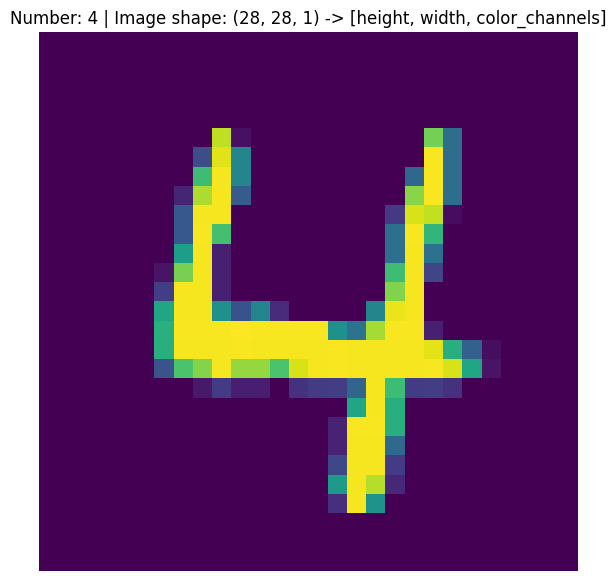

In [6]:
import matplotlib.pyplot as plt

img = X[42]

# Plot the image with matplotlib
plt.figure(figsize=(10, 7))
plt.imshow(img)
plt.title(f"Number: {y[42]} | Image shape: {img.shape} -> [height, width, color_channels]")
plt.axis(False);

### Convert to tensors

In [7]:
import torch
import numpy as np

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val.to_numpy(), dtype=torch.long)

X_train = X_train.permute(0, 3, 1, 2)
X_val = X_val.permute(0, 3, 1, 2)
X.shape

(42000, 28, 28, 1)

### Create dataloaders

In [8]:
from torch.utils.data import DataLoader, TensorDataset

# Create TensorDatasets
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

# Set-up the device
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## Model_0 Development
Design, train, and evaluate the model using the training and validation sets.

### Create a Model

In [9]:
y_val

tensor([8, 1, 9,  ..., 3, 0, 9])

In [10]:
from torch import nn

class TinyVGG(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3, # how big is the square that's going over the image?
                      stride=1, # default
                      padding=1), # options = "valid" (no padding) or "same" (output has same shape as input) or int for specific number
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Each layer of our network compresses and changes the shape of our input data.
            nn.Linear(in_features=hidden_units*7*7,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.conv_block_1(x)
        # print(x.shape)
        x = self.conv_block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x

torch.manual_seed(42)
model_0 = TinyVGG(input_shape=1, # number of color channels
                  hidden_units=32,
                  output_shape=len(y_val.unique())).to(device)
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=10, bias=True)
  )
)

### Create train & test loop functions

In [11]:
print(y_val.dtype, y_val.shape)
print(y_train.dtype, y_train.shape) # Verification target == int64

torch.int64 torch.Size([8400])
torch.int64 torch.Size([33600])


In [12]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        # Send data to target device
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [13]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            # Send data to target device
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

### Create a Train function to combine train and test function

In [14]:
from tqdm.auto import tqdm

# 1. Take in various parameters required for training and test steps
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):

    # 2. Create empty results dictionary
    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    # 3. Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        test_loss, test_acc = test_step(model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn)

        # 4. Print out what's happening
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    # 6. Return the filled results at the end of the epochs
    return results

### Train and Evaluate the model_0

In [15]:
# Set random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 20

# Recreate an instance of TinyVGG
model_0 = TinyVGG(input_shape=1, # number of color channels
                  hidden_units=32,
                  output_shape=len(y_val.unique())).to(device)

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_0
model_0_results = train(model=model_0,
                        train_dataloader=train_loader,
                        test_dataloader=val_loader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.2735 | train_acc: 0.9121 | test_loss: 0.0906 | test_acc: 0.9723
Epoch: 2 | train_loss: 0.0696 | train_acc: 0.9782 | test_loss: 0.0681 | test_acc: 0.9787
Epoch: 3 | train_loss: 0.0480 | train_acc: 0.9854 | test_loss: 0.0590 | test_acc: 0.9822
Epoch: 4 | train_loss: 0.0376 | train_acc: 0.9877 | test_loss: 0.0502 | test_acc: 0.9817
Epoch: 5 | train_loss: 0.0312 | train_acc: 0.9897 | test_loss: 0.0460 | test_acc: 0.9856
Epoch: 6 | train_loss: 0.0244 | train_acc: 0.9921 | test_loss: 0.0544 | test_acc: 0.9832
Epoch: 7 | train_loss: 0.0206 | train_acc: 0.9939 | test_loss: 0.0527 | test_acc: 0.9845
Epoch: 8 | train_loss: 0.0184 | train_acc: 0.9938 | test_loss: 0.0537 | test_acc: 0.9837
Epoch: 9 | train_loss: 0.0150 | train_acc: 0.9951 | test_loss: 0.0546 | test_acc: 0.9869
Epoch: 10 | train_loss: 0.0133 | train_acc: 0.9954 | test_loss: 0.0682 | test_acc: 0.9841
Epoch: 11 | train_loss: 0.0122 | train_acc: 0.9962 | test_loss: 0.0474 | test_acc: 0.9871
Epoch: 12 | train_l

### Plot the loss curves of Model 0

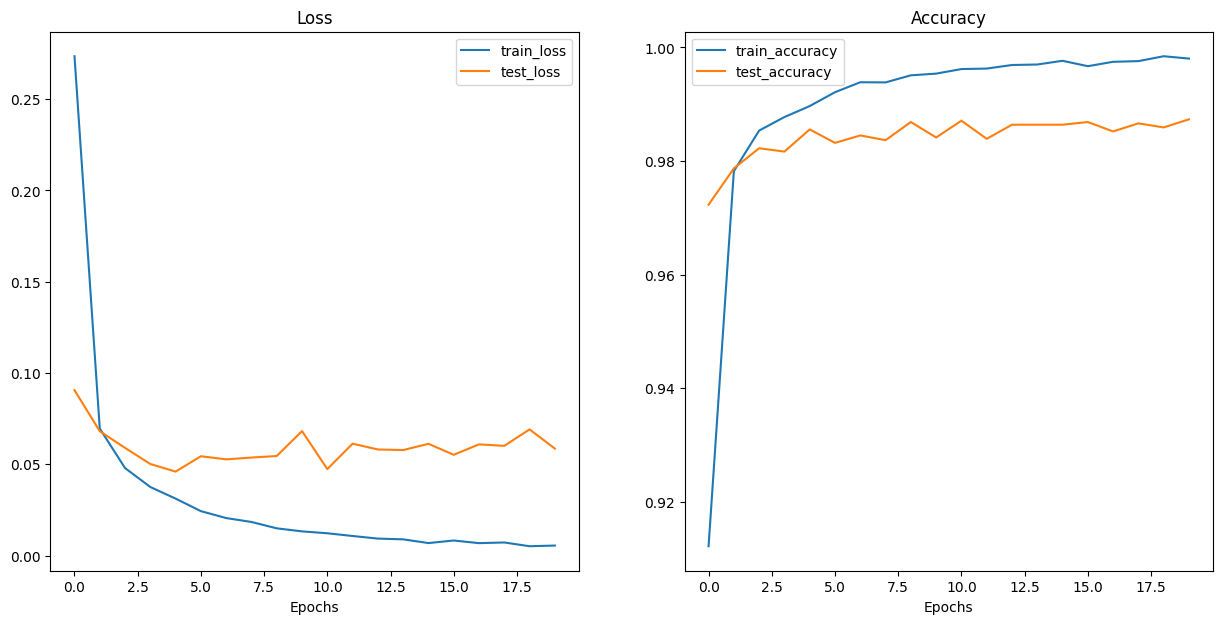

In [16]:
from typing import Dict, List

def plot_loss_curves(results: Dict[str, List[float]]):
    """Plots training curves of a results dictionary.

    Args:
        results (dict): dictionary containing list of values, e.g.
            {"train_loss": [...],
             "train_acc": [...],
             "test_loss": [...],
             "test_acc": [...]}
    """

    # Get the loss values of the results dictionary (training and test)
    loss = results['train_loss']
    test_loss = results['test_loss']

    # Get the accuracy values of the results dictionary (training and test)
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    # Figure out how many epochs there were
    epochs = range(len(results['train_loss']))

    # Setup a plot
    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend();

plot_loss_curves(model_0_results)


Although the validation accuracy remains high, the training loss keeps decreasing while the validation loss plateaus or increases, indicating overfitting. This suggests that the model (model_0) is memorizing the training data rather than learning to generalize.

To address this issue, we’ll introduce data augmentation using torchvision.transforms. This technique applies random, realistic modifications (like rotation or translation) to training images, helping the model learn more robust features and reduce overfitting.

## Model_0 Developement with Data Augmentation

### Define the transforms

In [17]:
import torchvision.transforms as transforms

"""
  I strarted with TrivialAugmentWide but
  it may be too aggressive for digits:
  It includes color and contrast changes
  that don’t apply to grayscale MNIST digits,
  so it might introduce noise. Best val accuracy: 0.9912 (epoch 38)
"""

# transform = transforms.Compose([
#     transforms.TrivialAugmentWide(num_magnitude_bins=31),
#     transforms.ToTensor()
# ])

transform = transforms.Compose([
    transforms.RandomAffine(
        degrees=10,             # small rotation
        translate=(0.1, 0.1),   # slight shift in x and y
        scale=(0.9, 1.1),       # slight zoom in/out
        shear=10                # shear for slanted digits
    ),
    transforms.ToTensor(),     # convert to tensor
])

### Create a custom dataset class

In [18]:
from torch.utils.data import Dataset

class CustomTensorDataset(Dataset):
    def __init__(self, tensors, transform=None):
        self.tensors = tensors
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.tensors[0][index], self.tensors[1][index]

        # Convert from (1, 28, 28) tensor to PIL image if needed
        if self.transform:
            x = transforms.ToPILImage()(x)  # Important!
            x = self.transform(x)

        return x, y

    def __len__(self):
        return len(self.tensors[0])

### Create the transform dataloader

In [19]:
train_dataset = CustomTensorDataset((X_train, y_train), transform=transform)
val_dataset = CustomTensorDataset((X_val, y_val))

train_loader_transform = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader_transform = DataLoader(val_dataset, batch_size=64, num_workers=2, pin_memory=True)

### Plot random images

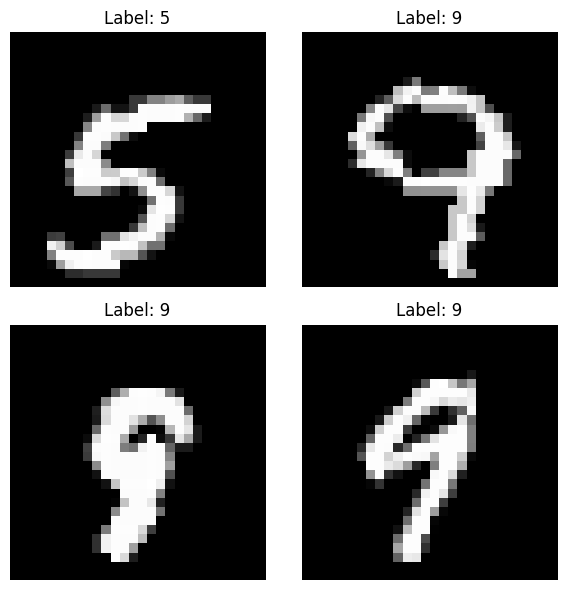

In [20]:
import random

# Get one batch from the train loader
images, labels = next(iter(train_loader_transform))

# Pick 4 random indices
rand_indices = random.sample(range(images.size(0)), 4)

# Plot the 4 images
fig, axs = plt.subplots(2, 2, figsize=(6, 6))
axs = axs.flatten()

for i, idx in enumerate(rand_indices):
    img = images[idx].squeeze()
    label = labels[idx].item()
    axs[i].imshow(img, cmap='gray')
    axs[i].set_title(f"Label: {label}")
    axs[i].axis('off')

plt.tight_layout()
plt.show()

### Train Model_1 (data augmentation)

In [21]:
# Set random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 20

# Recreate an instance of TinyVGG
model_0 = TinyVGG(input_shape=1, # number of color channels
                  hidden_units=32,
                  output_shape=len(y_val.unique())).to(device)

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_0
model_0_results_transform = train(model=model_0,
                                  train_dataloader=train_loader_transform,
                                  test_dataloader=val_loader_transform,
                                  optimizer=optimizer,
                                  loss_fn=loss_fn,
                                  epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.5063 | train_acc: 0.8333 | test_loss: 0.0924 | test_acc: 0.9734
Epoch: 2 | train_loss: 0.1686 | train_acc: 0.9494 | test_loss: 0.0664 | test_acc: 0.9792
Epoch: 3 | train_loss: 0.1259 | train_acc: 0.9618 | test_loss: 0.0667 | test_acc: 0.9776
Epoch: 4 | train_loss: 0.1015 | train_acc: 0.9685 | test_loss: 0.0447 | test_acc: 0.9858
Epoch: 5 | train_loss: 0.0854 | train_acc: 0.9729 | test_loss: 0.0425 | test_acc: 0.9853
Epoch: 6 | train_loss: 0.0781 | train_acc: 0.9754 | test_loss: 0.0369 | test_acc: 0.9889
Epoch: 7 | train_loss: 0.0689 | train_acc: 0.9779 | test_loss: 0.0337 | test_acc: 0.9891
Epoch: 8 | train_loss: 0.0684 | train_acc: 0.9793 | test_loss: 0.0377 | test_acc: 0.9877
Epoch: 9 | train_loss: 0.0592 | train_acc: 0.9804 | test_loss: 0.0345 | test_acc: 0.9890
Epoch: 10 | train_loss: 0.0563 | train_acc: 0.9823 | test_loss: 0.0266 | test_acc: 0.9915
Epoch: 11 | train_loss: 0.0558 | train_acc: 0.9826 | test_loss: 0.0285 | test_acc: 0.9903
Epoch: 12 | train_l

### Plot the loss curves of Model 0_transform

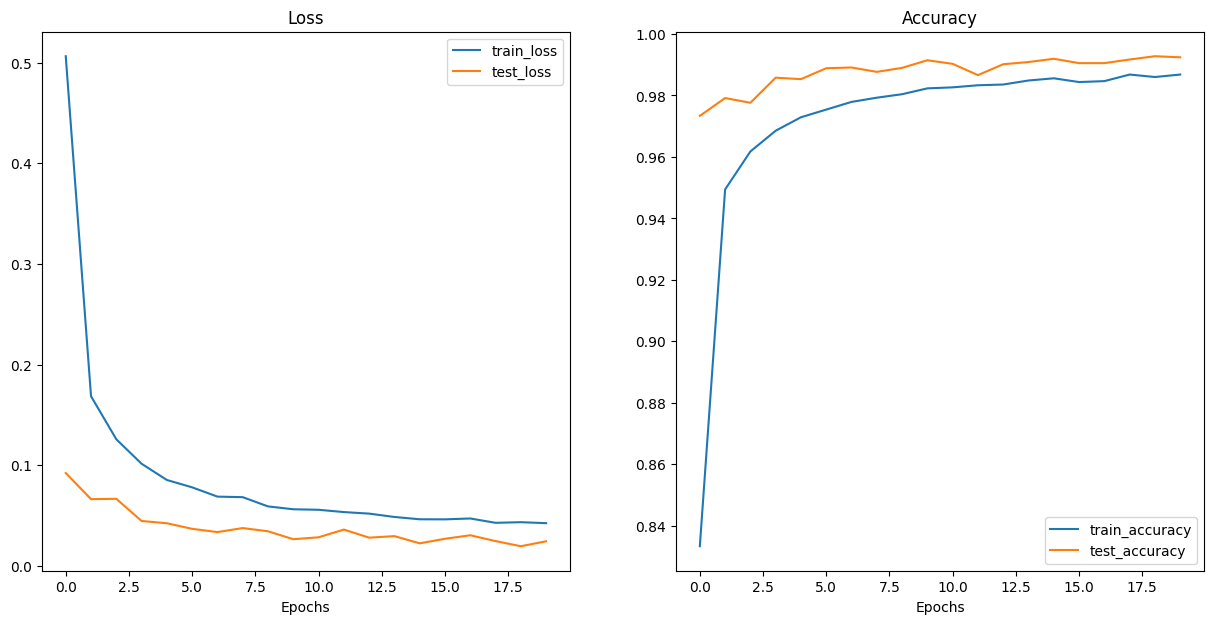

In [22]:
plot_loss_curves(model_0_results_transform)

### 🔄 Transform Strategy Update

## 🔄 Transform Strategy Update

I started with `TrivialAugmentWide`, but it turned out to be too aggressive for grayscale MNIST digits, as it includes color and contrast changes that aren't relevant and may introduce noise.  
🧪 **Best validation accuracy with TrivialAugmentWide**: 0.9912 (epoch 38)

I then switched to a more task-specific augmentation using `RandomAffine` (small rotation, translation, zoom, and shear), which worked **faster and better**:  
✅ **Reached >99% validation accuracy by epoch 10**, and the loss kept decreasing steadily.

📉 We can clearly see on the training/validation graphs that the model is **not overfitting**, so we will **continue training longer** using **early stopping and learning rate scheduling** to maximize performance while avoiding overtraining.



## Model_0 with early stop and learning rate scheduling

### Create the train function with early stop and scheduler

In [23]:
from tqdm.auto import tqdm

# 1. Take in various parameters required for training and test steps
def train_early_stop(model: torch.nn.Module,
                      train_dataloader: torch.utils.data.DataLoader,
                      test_dataloader: torch.utils.data.DataLoader,
                      optimizer: torch.optim.Optimizer,
                      scheduler: torch.optim.lr_scheduler.StepLR,
                      loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
                      epochs: int = 5,
                      patience=5):

    # 2. Create empty results dictionary
    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }
    best_val_loss = np.inf  # Start with a large value
    epochs_no_improve = 0  # Counter for early stopping
    early_stop = False  # Flag to stop training
    # 3. Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        test_loss, test_acc = test_step(model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn)

        # 4. Print out what's happening
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # Scheduler step (adjust learning rate)
        scheduler.step()

        # Early Stopping check
        if test_loss < best_val_loss:
            best_val_loss = test_loss
            epochs_no_improve = 0  # Reset counter when improvement is found
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early stopping after {epoch + 1} epochs.")
            early_stop = True
            break


        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    # 6. Return the filled results at the end of the epochs
    return results

### Early Stopping parameters

In [25]:
patience = 5  # Number of epochs to wait for improvement
best_val_loss = np.inf  # Start with a large value
epochs_no_improve = 0  # Counter for early stopping
early_stop = False  # Flag to stop training

### Train and eval the model

In [35]:
from torch.optim.lr_scheduler import StepLR

# Set random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 50

# Recreate an instance of TinyVGG
model_0 = TinyVGG(input_shape=1, # number of color channels
                  hidden_units=128, # Better option
                  output_shape=len(y_val.unique())).to(device)

# Create optimizer and scheduler
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)
scheduler = StepLR(optimizer, step_size=10, gamma=0.1)
loss_fn = nn.CrossEntropyLoss()

# Start the timer
start_time = timer()

# Train model_0
model_with_early_stop_and_scheduler_results = train_early_stop(model=model_0,
                                            train_dataloader=train_loader_transform,
                                            test_dataloader=val_loader_transform,
                                            optimizer=optimizer,
                                            loss_fn=loss_fn,
                                            epochs=NUM_EPOCHS,
                                            scheduler=scheduler,
                                            patience=5)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.3157 | train_acc: 0.8958 | test_loss: 0.0644 | test_acc: 0.9798
Epoch: 2 | train_loss: 0.1046 | train_acc: 0.9684 | test_loss: 0.0447 | test_acc: 0.9850
Epoch: 3 | train_loss: 0.0754 | train_acc: 0.9768 | test_loss: 0.0309 | test_acc: 0.9892
Epoch: 4 | train_loss: 0.0666 | train_acc: 0.9797 | test_loss: 0.0368 | test_acc: 0.9879
Epoch: 5 | train_loss: 0.0585 | train_acc: 0.9818 | test_loss: 0.0319 | test_acc: 0.9889
Epoch: 6 | train_loss: 0.0522 | train_acc: 0.9841 | test_loss: 0.0255 | test_acc: 0.9920
Epoch: 7 | train_loss: 0.0501 | train_acc: 0.9847 | test_loss: 0.0219 | test_acc: 0.9934
Epoch: 8 | train_loss: 0.0448 | train_acc: 0.9865 | test_loss: 0.0311 | test_acc: 0.9906
Epoch: 9 | train_loss: 0.0420 | train_acc: 0.9869 | test_loss: 0.0220 | test_acc: 0.9931
Epoch: 10 | train_loss: 0.0406 | train_acc: 0.9879 | test_loss: 0.0226 | test_acc: 0.9930
Epoch: 11 | train_loss: 0.0255 | train_acc: 0.9919 | test_loss: 0.0166 | test_acc: 0.9954
Epoch: 12 | train_l

### Plot the loss curves of Model_1

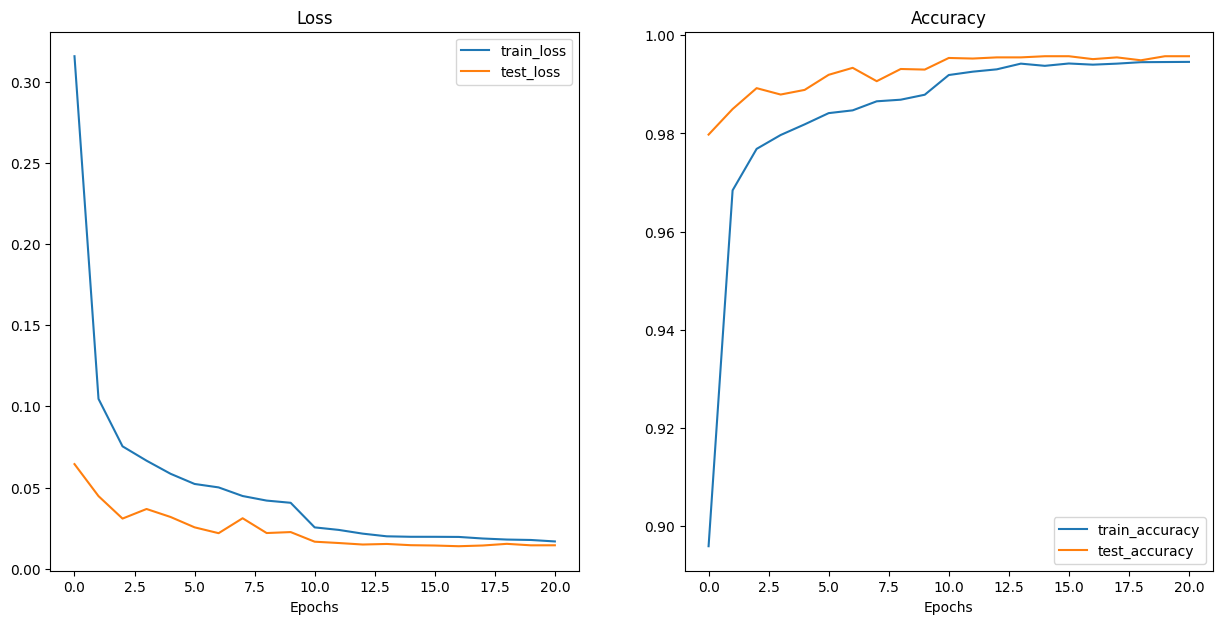

In [36]:
plot_loss_curves(model_with_early_stop_and_scheduler_results)

### Save the model state_dict

In [37]:
# Save the model's state_dict (weights) to a .pth file
torch.save(model_0.state_dict(), "model_0_best.pth")

# Load the model weights into the model
# model_0.load_state_dict(torch.load("model_0_best.pth"))
# model_0.eval()  # Set the model to evaluation mode (important for inference)


The best-performing model, model_0, combines early stopping with data-specific transformations. It achieved excellent results at epoch 22 with a training loss of 0.0164, training accuracy of 99.50%, test loss of 0.0145, and test accuracy of 99.61%. The training curves show no signs of underfitting or overfitting, indicating a well-generalized model. After experimenting with different hidden layer sizes, 124 units yielded the best performance.

To further challenge the custom model, we import a pretrained ResNet model and fine-tune it on our dataset. This allows us to compare performance between a handcrafted architecture and a state-of-the-art transfer learning approach to determine which generalizes better on our task.

## Model transfer and adaptation with the data

### Import Model Resnet and load the data


In [44]:
# Transform for preprocessing the MNIST images
transform_resnet = transforms.Compose([
    transforms.Resize(224),  # Resizing to match the input size for ResNet
    transforms.Grayscale(num_output_channels=3),  # Convert to 3 channels
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Standard normalization for ResNet
])

train_dataset_resnet = CustomTensorDataset((X_train, y_train), transform=transform_resnet)
val_dataset_resnet = CustomTensorDataset((X_val, y_val), transform=transform_resnet) # To put 3 channels

train_loader_transform_resnet = DataLoader(train_dataset_resnet, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
test_loader_transform_resnet = DataLoader(val_dataset_resnet, batch_size=64, num_workers=2, pin_memory=True)

### Modify the Model for MNIST (10 classes)

In [45]:
from torchvision import models

# Load pre-trained ResNet18 model
model = models.resnet18(pretrained=True)

# Modify the final layer to match the number of classes (10 for MNIST)
model.fc = nn.Linear(model.fc.in_features, 10)  # 10 classes for MNIST

# Move model to device (GPU or CPU)
model = model.to(device)

### Define the Loss and Optimizer



In [46]:

# Define the loss function
loss_fn = nn.CrossEntropyLoss()

# Define the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### Train the Model

In [47]:
# Set random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 50

# Start the timer
start_time = timer()

# Train model_ResNet
model_resnet_results = train_early_stop(model=model,
                                            train_dataloader=train_loader_transform_resnet,
                                            test_dataloader=test_loader_transform_resnet,
                                            optimizer=optimizer,
                                            loss_fn=loss_fn,
                                            epochs=NUM_EPOCHS,
                                            scheduler=scheduler,
                                            patience=5)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.0813 | train_acc: 0.9757 | test_loss: 0.0390 | test_acc: 0.9872
Epoch: 2 | train_loss: 0.0407 | train_acc: 0.9877 | test_loss: 0.0366 | test_acc: 0.9889
Epoch: 3 | train_loss: 0.0290 | train_acc: 0.9909 | test_loss: 0.0311 | test_acc: 0.9906
Epoch: 4 | train_loss: 0.0266 | train_acc: 0.9921 | test_loss: 0.0299 | test_acc: 0.9898
Epoch: 5 | train_loss: 0.0201 | train_acc: 0.9940 | test_loss: 0.0320 | test_acc: 0.9895
Epoch: 6 | train_loss: 0.0202 | train_acc: 0.9938 | test_loss: 0.0277 | test_acc: 0.9912
Epoch: 7 | train_loss: 0.0188 | train_acc: 0.9937 | test_loss: 0.0335 | test_acc: 0.9904
Epoch: 8 | train_loss: 0.0130 | train_acc: 0.9957 | test_loss: 0.0395 | test_acc: 0.9892
Epoch: 9 | train_loss: 0.0154 | train_acc: 0.9950 | test_loss: 0.0248 | test_acc: 0.9930
Epoch: 10 | train_loss: 0.0125 | train_acc: 0.9963 | test_loss: 0.0303 | test_acc: 0.9911
Epoch: 11 | train_loss: 0.0082 | train_acc: 0.9974 | test_loss: 0.0356 | test_acc: 0.9909
Epoch: 12 | train_l

### Plot the loss curves of Model_1

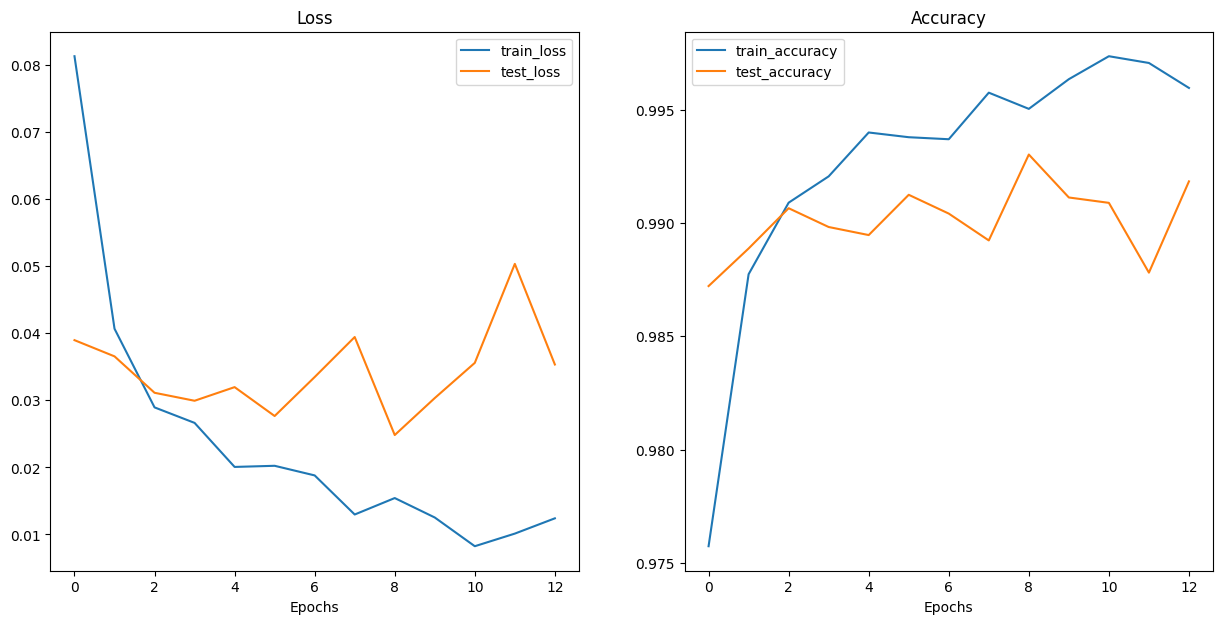

In [48]:
plot_loss_curves(model_resnet_results)


### 📊 Model Comparison: Custom CNN vs. Pretrained ResNet18

| Metric       | Custom CNN (model_0) | ResNet18 (pretrained) |
|--------------|----------------------|------------------------|
| Epoch Stopped| 22                   | 14              |
| Train Loss   | 0.0164           | 0.0056      |
| Train Acc    | 99.50%       | 99.82%  |
| Test Loss    | 0.0145            | 0.0433       |
| Test Acc     | 99.61%        | 98.84%   |

---

### ✅ Conclusion

Although ResNet18 shows slightly better **training accuracy**, it overfits the training data more, as reflected in the higher **test loss** and lower **test accuracy**.

**➡️ Custom model_0 performs better in generalization**, achieving higher test accuracy with fewer resources and a smaller architecture. Ideal for MNIST-scale datasets.


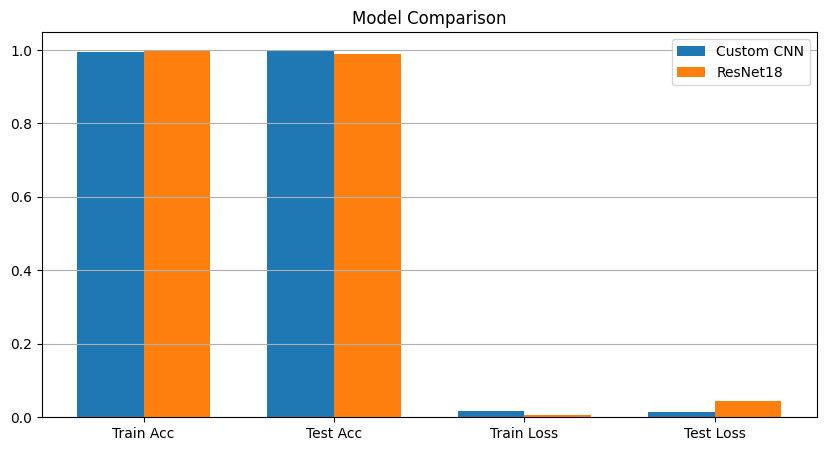

In [49]:

# --- Results for model_0 ---
model_0_results = {
    "train_loss": 0.0164,
    "train_acc": 0.9950,
    "test_loss": 0.0145,
    "test_acc": 0.9961,
    "epochs": 22
}

# --- Results for ResNet18 ---
resnet_results = {
    "train_loss": 0.0056,
    "train_acc": 0.9982,
    "test_loss": 0.0433,
    "test_acc": 0.9884,
    "epochs": 14
}

# --- Display comparison table ---
from IPython.display import display, Markdown

comparison_md = f"""
### 📊 Model Comparison: Custom CNN vs. Pretrained ResNet18

| Metric       | Custom CNN (model_0) | ResNet18 (pretrained) |
|--------------|----------------------|------------------------|
| Epoch Stopped| {model_0_results['epochs']}                   | {resnet_results['epochs']}              |
| Train Loss   | {model_0_results['train_loss']:.4f}           | {resnet_results['train_loss']:.4f}      |
| Train Acc    | {model_0_results['train_acc']*100:.2f}%       | {resnet_results['train_acc']*100:.2f}%  |
| Test Loss    | {model_0_results['test_loss']:.4f}            | {resnet_results['test_loss']:.4f}       |
| Test Acc     | {model_0_results['test_acc']*100:.2f}%        | {resnet_results['test_acc']*100:.2f}%   |

---

### ✅ Conclusion

Although ResNet18 shows slightly better **training accuracy**, it overfits the training data more, as reflected in the higher **test loss** and lower **test accuracy**.

**➡️ Custom model_0 performs better in generalization**, achieving higher test accuracy with fewer resources and a smaller architecture. Ideal for MNIST-scale datasets.
"""

display(Markdown(comparison_md))

# --- Optional: Bar plot for quick visual comparison ---
labels = ['Train Acc', 'Test Acc', 'Train Loss', 'Test Loss']
model_0_vals = [model_0_results['train_acc'], model_0_results['test_acc'],
                model_0_results['train_loss'], model_0_results['test_loss']]
resnet_vals = [resnet_results['train_acc'], resnet_results['test_acc'],
               resnet_results['train_loss'], resnet_results['test_loss']]

x = range(len(labels))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar([p - width/2 for p in x], model_0_vals, width=width, label='Custom CNN')
plt.bar([p + width/2 for p in x], resnet_vals, width=width, label='ResNet18')
plt.xticks(ticks=x, labels=labels)
plt.title("Model Comparison")
plt.legend()
plt.grid(axis='y')
plt.show()


To ensure that the performance of model_0 is optimal, we'll retrain it using 256 hidden units to evaluate whether increasing the model's capacity leads to any meaningful improvement in accuracy or generalization.

## Model_0 with 256 hidden units

In [51]:

# Set random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 50

# Recreate an instance of TinyVGG
model_0 = TinyVGG(input_shape=1, # number of color channels
                  hidden_units=256, # Better option
                  output_shape=len(y_val.unique())).to(device)

# Create optimizer and scheduler
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)
scheduler = StepLR(optimizer, step_size=10, gamma=0.1)
loss_fn = nn.CrossEntropyLoss()

# Start the timer
start_time = timer()

# Train model_0
model__256_hidden_units = train_early_stop(model=model_0,
                                            train_dataloader=train_loader_transform,
                                            test_dataloader=val_loader_transform,
                                            optimizer=optimizer,
                                            loss_fn=loss_fn,
                                            epochs=NUM_EPOCHS,
                                            scheduler=scheduler,
                                            patience=5)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.3638 | train_acc: 0.8823 | test_loss: 0.0569 | test_acc: 0.9834
Epoch: 2 | train_loss: 0.1135 | train_acc: 0.9659 | test_loss: 0.0427 | test_acc: 0.9857
Epoch: 3 | train_loss: 0.0821 | train_acc: 0.9754 | test_loss: 0.0497 | test_acc: 0.9841
Epoch: 4 | train_loss: 0.0705 | train_acc: 0.9780 | test_loss: 0.0275 | test_acc: 0.9904
Epoch: 5 | train_loss: 0.0634 | train_acc: 0.9801 | test_loss: 0.0304 | test_acc: 0.9904
Epoch: 6 | train_loss: 0.0552 | train_acc: 0.9826 | test_loss: 0.0315 | test_acc: 0.9902
Epoch: 7 | train_loss: 0.0515 | train_acc: 0.9842 | test_loss: 0.0243 | test_acc: 0.9911
Epoch: 8 | train_loss: 0.0459 | train_acc: 0.9852 | test_loss: 0.0226 | test_acc: 0.9925
Epoch: 9 | train_loss: 0.0477 | train_acc: 0.9851 | test_loss: 0.0218 | test_acc: 0.9936
Epoch: 10 | train_loss: 0.0430 | train_acc: 0.9867 | test_loss: 0.0219 | test_acc: 0.9934
Epoch: 11 | train_loss: 0.0296 | train_acc: 0.9912 | test_loss: 0.0160 | test_acc: 0.9944
Epoch: 12 | train_l

### Plot the model

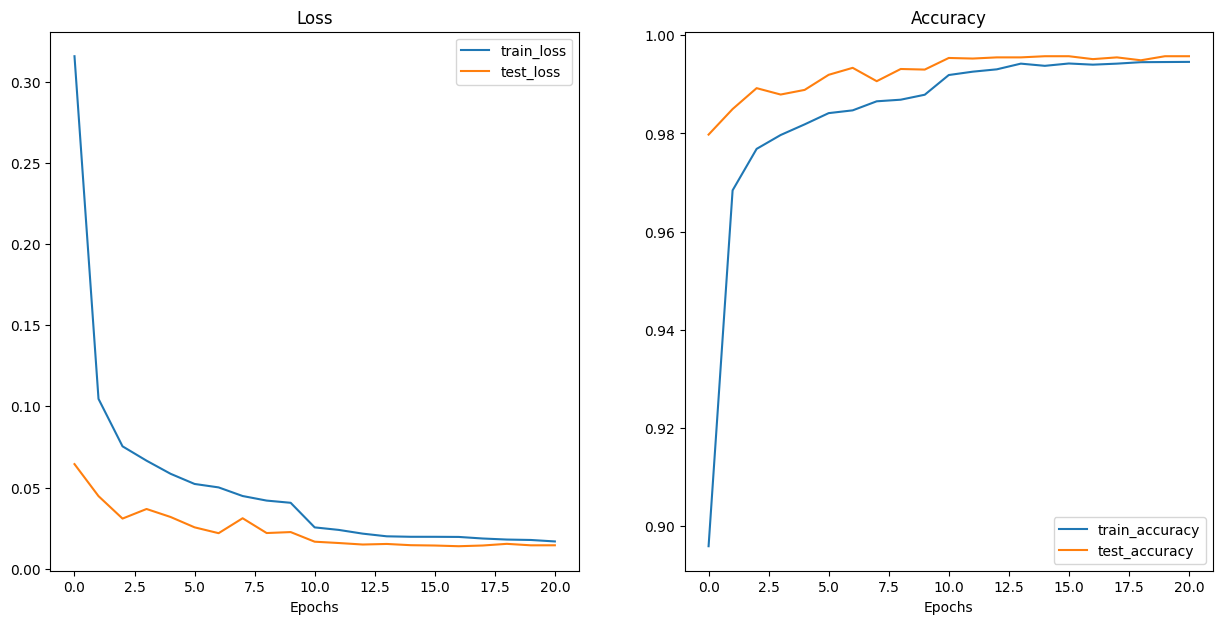

In [52]:
plot_loss_curves(model_with_early_stop_and_scheduler_results)

## 🔍 Model Comparison: TinyVGG (124 vs 256 Hidden Units)

We experimented with two configurations of the `TinyVGG` model to find the optimal number of hidden units for our classification task.

### 📊 Results Overview

| Metric             | TinyVGG (124 units)       | TinyVGG (256 units)       |
|--------------------|---------------------------|----------------------------|
| **Epoch Stopped**  | 22                        | 21                         |
| **Train Loss**     | 0.0164                    | 0.0217                     |
| **Train Accuracy** | 99.50%                    | 99.35%                     |
| **Test Loss**      | 0.0145                    | 0.0138                     |
| **Test Accuracy**  | **99.61%**                | 99.51%                     |
| **Training Time**  | ⏱️ 283.8 seconds          | ⏱️ 429.6 seconds           |

---

### ✅ Conclusion

While the model with **256 hidden units** achieved a marginally lower test loss, the **124 hidden unit version reached higher test accuracy and trained faster**.  
This makes the 124-hidden-units model a better choice overall in terms of both performance and efficiency.


## Model Evaluation and Deployment




### Prepare the DataLoader

In [69]:
# Load the CSV
test_df = pd.read_csv("data/test.csv")

# Convert to tensor and reshape to (N, 1, 28, 28)
X_test = torch.tensor(test_df.values / 255., dtype=torch.float32).reshape(-1, 1, 28, 28)

### Load the model

In [70]:


# Recreate the custom model (TinyVGG)
model_0 = TinyVGG(input_shape=1, hidden_units=128, output_shape=10).to(device)

# Load the saved model weights
model_0.load_state_dict(torch.load("model_0_best.pth"))
model_0.eval()  # Set model to evaluation mode


TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6272, out_features=10, bias=True)
  )
)

### Defining the Transforms



In [ ]:
# --- Transforms ---
transform = transforms.Compose([
    transforms.RandomAffine(
        degrees=10,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1),
        shear=10
    ),
    transforms.ToTensor(),
])


### Custom Dataset Class

In [ ]:
# --- MODIFIED Custom Dataset class ---
class CustomTestDataset(Dataset):
    def __init__(self, images, transform=None):
        self.images = images
        self.transform = transform
        self.to_pil = transforms.ToPILImage()

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_data = self.images[idx]
        if isinstance(img_data, torch.Tensor):
            img_data_cpu = img_data.cpu()
            if img_data_cpu.ndim == 2:
                img_data_cpu = img_data_cpu.unsqueeze(0)
            img = self.to_pil(img_data_cpu)
        elif isinstance(img_data, np.ndarray):
            if img_data.dtype == np.float32 or img_data.dtype == np.float64:
                img_data = (img_data * 255).astype(np.uint8)
            if img_data.ndim == 2:
                img = Image.fromarray(img_data, mode='L') # Grayscale
            elif img_data.ndim == 3:
                img = Image.fromarray(img_data, mode='RGB') # RGB
        elif isinstance(img_data, Image.Image):
            img = img_data
        else:
            raise TypeError(f"Unsupported data type in dataset: {type(img_data)}")

        if self.transform:
            img = self.transform(img) # Applies RandomAffine then ToTensor
        return img


###  Create Dataset and DataLoader

In [ ]:
# --- Create dataset and dataloader ---
test_dataset = CustomTestDataset(X_test, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # Use a reasonable batch size

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Prediction Loop

In [ ]:
# --- Prediction Loop (Using Tensor Collection) ---
prediction_tensors_cpu = [] # To store prediction tensors from each batch (on CPU)
print("Starting prediction loop...")
with torch.inference_mode():
    for batch_idx, images in enumerate(test_loader):
        try:
            images = images.to(device)  # Move images to device

            # Get model predictions
            outputs = model_0(images)
            _, predicted = torch.max(outputs, 1) # Get the index (predicted class)

            # Append the CPU tensor to the list
            prediction_tensors_cpu.append(predicted.cpu())

        except Exception as e:
            print(f"!!! ERROR in batch {batch_idx}: {type(e).__name__}: {e}")
            raise e # Stop execution on error during debugging

print("Finished prediction loop.")

### Process Predictions and Create DataFrame

In [72]:
# --- Process Predictions and Create DataFrame ---
if prediction_tensors_cpu: # Check if any predictions were made
    try:
        print("Concatenating prediction tensors...")
        all_predictions_tensor = torch.cat(prediction_tensors_cpu)

        print("Converting final tensor to NumPy array...")
        final_predicted_labels = all_predictions_tensor.numpy()

        # Get the total number of predictions made
        num_predictions = len(final_predicted_labels)
        print(f"Total predictions generated: {num_predictions}")

        # Generate ImageId sequence: starting from 1 up to num_predictions
        image_ids = list(range(1, num_predictions + 1))
        print(f"Generated ImageIDs from 1 to {num_predictions}")

        # Create a dictionary mapping column names to the data
        submission_data = {
            'ImageId': image_ids,
            'Label': final_predicted_labels # This is the NumPy array of predictions
        }

        # Create the Pandas DataFrame from the dictionary
        print("Creating Pandas DataFrame with 'ImageId' and 'Label' columns...")
        submission_df = pd.DataFrame(submission_data)
        print("DataFrame created successfully.")
        print(submission_df.head()) # Display the first few rows

        # Save the DataFrame to a CSV file, without the pandas index
        output_filename = "submission.csv" # A common name for submission files
        print(f"Saving DataFrame to {output_filename}...")
        submission_df.to_csv(output_filename, index=False)
        print(f"Predictions saved successfully to {output_filename}")

    except Exception as e:
        print(f"\n---!!! ERROR during final processing or DataFrame creation: {type(e).__name__}: {e} !!!---")
        if 'final_predicted_labels' in locals():
             print(f"Shape of final_predicted_labels: {final_predicted_labels.shape}")
        if 'image_ids' in locals():
             print(f"Length of image_ids: {len(image_ids)}")

else:
    print("ERROR: No predictions were collected. Check the prediction loop and data loader.")

Starting prediction loop...
Finished prediction loop.
Concatenating prediction tensors...
Converting final tensor to NumPy array...
Total predictions generated: 28000
Generated ImageIDs from 1 to 28000
Creating Pandas DataFrame with 'ImageId' and 'Label' columns...
DataFrame created successfully.
   ImageId  Label
0        1      2
1        2      0
2        3      9
3        4      0
4        5      3
Saving DataFrame to submission.csv...
Predictions saved successfully to submission.csv
